# Exploratory Data Analysis – NIL Research Project
**ECC3479 | Data and Evidence in Economics | Monash University**  
**Group:** Elena Langridge, Teah Papageorgiou, Lily Proposch  
**Dataset:** California public Division I universities, 2021–2024  

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Characteristics](#2-data-characteristics)
   - 2.1 Dataset Overview & Cleaning Impact
   - 2.2 Variable Descriptions and Distributions
   - 2.3 Expectations vs Reality
3. [Exploratory Analysis of Variable Correlations](#3-exploratory-analysis-of-variable-correlations)
   - 3.1 First-Order Effect: Social Media on Deal Amounts
   - 3.2 Temporal Trends and Confounding
   - 3.3 Simpson's Paradox and Sport-Level Heterogeneity
   - 3.4 School and Institutional Effects


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import os

# ── reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
BLUE, ORANGE, GREEN, RED = "#4C72B0", "#DD8452", "#55A868", "#C44E52"

# ── Dynamically find data directory ──────────────────────────────────────────
# Start from current notebook location and search upward for 'data' folder
current_dir = Path.cwd()
print(f"Current working directory: {current_dir}")

# Try multiple possible data paths
possible_paths = [
    current_dir / "data" / "clean" / "cleaned_nil.csv",
    current_dir.parent / "data" / "clean" / "cleaned_nil.csv",
    current_dir.parent.parent / "data" / "clean" / "cleaned_nil.csv",
    Path("/Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/data/clean/cleaned_nil.csv"),
]

clean_path = None
for path in possible_paths:
    if path.exists():
        clean_path = path
        print(f"✓ Found cleaned_nil.csv at: {clean_path}")
        break

if clean_path is None:
    print("✗ Could not find cleaned_nil.csv. Available paths checked:")
    for path in possible_paths:
        print(f"  - {path}")
    print("\nPlease manually set the correct path below:")
    clean_path = Path("data/clean/cleaned_nil.csv")  # Fallback

agg_path = clean_path.parent / "nil_merged_analysis.csv"

print(f"Loading from:")
print(f"  Transaction-level: {clean_path}")
print(f"  Aggregated: {agg_path}")

# ── Load datasets ────────────────────────────────────────────────────────────
try:
    df_clean = pd.read_csv(clean_path)
    df_agg   = pd.read_csv(agg_path)
    print("✓ Data loaded successfully")
except FileNotFoundError as e:
    print(f"✗ Error loading data: {e}")
    print("\nTo fix this:")
    print("1. Check that 'data/clean/' directory exists in your project root")
    print("2. Verify filenames: 'cleaned_nil.csv' and 'nil_merged_analysis.csv'")
    print("3. Update paths below if files are located elsewhere")
    raise

# rename 'date' column to 'year' for clarity in df_clean
if "date" in df_clean.columns:
    df_clean = df_clean.rename(columns={"date": "year"})
elif "year" not in df_clean.columns:
    print("Warning: Neither 'date' nor 'year' column found in transaction dataset")

print(f"\nTransaction-level dataset  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Aggregated analysis dataset: {df_agg.shape[0]:,} rows × {df_agg.shape[1]} columns")
print("\nFirst few rows of aggregated dataset:")
print(df_agg.head())

Current working directory: /Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/code
✓ Found cleaned_nil.csv at: /Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/data/clean/cleaned_nil.csv
Loading from:
  Transaction-level: /Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/data/clean/cleaned_nil.csv
  Aggregated: /Users/elenalangridge/Desktop/University 2026 /ECC3479 - Data and Evidence in Economics /Project /Data + GitHub repo/nil-research-project/data/clean/nil_merged_analysis.csv
✓ Data loaded successfully

Transaction-level dataset  : 2,347 rows × 6 columns
Aggregated analysis dataset: 374 rows × 5 columns

First few rows of aggregated dataset:
         school       sport  year  is_social_media  avg_transaction_value
0    ca

## 2. Data Characteristics

This section describes each variable's distribution, whether observations align with expectations, and what the data-cleaning pipeline changed.

### 2.1 Dataset Overview & Impact of Data Cleaning

In [2]:
# ── Summary statistics ───────────────────────────────────────────────────────
print("=== Aggregated dataset – summary statistics ===")
print(df_agg.describe().round(2).to_string())

print()
print("=== Transaction-level dataset – summary statistics ===")
print(df_clean[["amount", "year", "is_social_media"]].describe().round(2).to_string())


=== Aggregated dataset – summary statistics ===
          year  is_social_media  avg_transaction_value
count   374.00           374.00                 374.00
mean   2022.75             0.45                2312.84
std       1.12             0.50                8432.38
min    2021.00             0.00                   0.01
25%    2022.00             0.00                  75.00
50%    2023.00             0.00                 180.49
75%    2024.00             1.00                 600.00
max    2025.00             1.00               84290.29

=== Transaction-level dataset – summary statistics ===
          amount     year  is_social_media
count    2347.00  2347.00          2347.00
mean     4024.12  2022.87             0.42
std     22313.71     1.01             0.49
min         0.01  2021.00             0.00
25%        60.00  2022.00             0.00
50%       250.00  2023.00             0.00
75%      1000.00  2024.00             1.00
max    450000.00  2025.00             1.00


**What the cleaning pipeline did:**

| Step | Action | Effect |
|------|--------|--------|
| Column harmonisation | Mapped 15+ raw header variants (`Amount`, `Total NIL`, `Cost`, …) to a single `amount` field | Enabled concatenation across 12 schools |
| School exclusions | `fresnostate1` and `sandiegostate1` dropped (missing `amount`); Cal State Northridge and San Jose State reported no deals | Reduces sample to 12 schools; introduces selection bias toward schools that actively reported |
| Amount cleaning | Stripped `$` and `,`; coerced non-numeric values to `NaN`; dropped rows with `amount ≤ 0` | Retains 2,347 transaction-level rows with positive deal values |
| Date imputation | Parsed multiple date formats; where no date could be inferred, year assigned randomly from {2021–2024} | Introduces measurement noise in `year` for ~a minority of rows – treat temporal results with caution |
| `is_social_media` derivation | Keyword regex on `deal_description` (social media, instagram, tiktok, post, tweet) | Binary treatment variable; may misclassify edge cases |
| UC San Diego special rule | Blank `Notes` → coded as Social Media | School-specific assumption; inflates social media share for that school |
| Aggregation | Transaction rows grouped by (school, sport, year, `is_social_media`) and averaged | 2,347 transactions → 371 school-sport-year-type groups |

### 2.2 Variable Descriptions and Distributions

#### `school` — Categorical (12 universities)

/var/folders/c0/430h3c1d5g5d8rc2z8nngyw40000gn/T/ipykernel_971/2172736933.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(school_counts.index, rotation=40, ha="right")


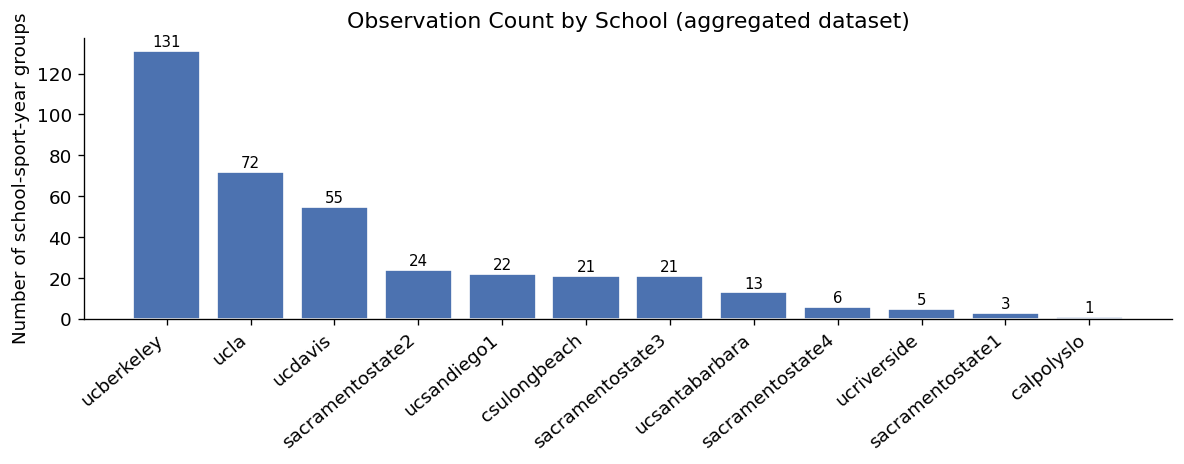

school
ucberkeley          131
ucla                 72
ucdavis              55
sacramentostate2     24
ucsandiego1          22
csulongbeach         21
sacramentostate3     21
ucsantabarbara       13
sacramentostate4      6
ucriverside           5
sacramentostate1      3
calpolyslo            1


In [3]:
school_counts = df_agg["school"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(school_counts.index, school_counts.values, color=BLUE, edgecolor="white")
ax.set_ylabel("Number of school-sport-year groups")
ax.set_title("Observation Count by School (aggregated dataset)")
ax.set_xticklabels(school_counts.index, rotation=40, ha="right")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(school_counts.to_string())


**Justification:** UC Berkeley (129 groups) and UCLA (72 groups) together account for ~54% of the aggregated observations. This reflects the larger athletic programmes at flagship UC campuses. The skew toward these schools means model estimates may be influenced disproportionately by their NIL reporting practices, so school fixed effects will be important in the primary analysis to isolate within-school variation.

#### `year` — Numeric (2021–2025)

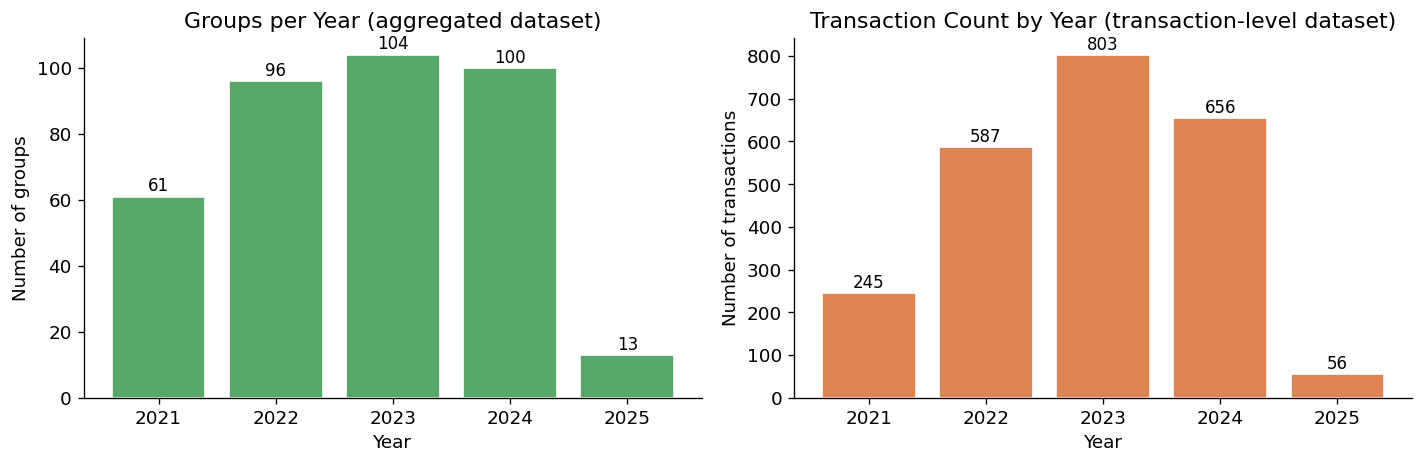

Groups per year (agg): {2021: np.int64(61), 2022: np.int64(96), 2023: np.int64(104), 2024: np.int64(100), 2025: np.int64(13)}
Transactions per year (clean): {2021: np.int64(245), 2022: np.int64(587), 2023: np.int64(803), 2024: np.int64(656), 2025: np.int64(56)}

Note: 2025 has only 13 groups / 56 transactions – likely partial-year reporting.


In [4]:
year_counts = df_agg["year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: count of groups per year
axes[0].bar(year_counts.index, year_counts.values, color=GREEN, edgecolor="white")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of groups")
axes[0].set_title("Groups per Year (aggregated dataset)")
for x, y in zip(year_counts.index, year_counts.values):
    axes[0].text(x, y + 0.5, str(y), ha="center", va="bottom", fontsize=10)

# Right: count of transactions per year
year_tx = df_clean["year"].value_counts().sort_index()
axes[1].bar(year_tx.index, year_tx.values, color=ORANGE, edgecolor="white")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of transactions")
axes[1].set_title("Transaction Count by Year (transaction-level dataset)")
for x, y in zip(year_tx.index, year_tx.values):
    axes[1].text(x, y + 3, str(y), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print("Groups per year (agg):", dict(year_counts))
print("Transactions per year (clean):", dict(year_tx))
print()
print("Note: 2025 has only 13 groups / 56 transactions – likely partial-year reporting.")


**Justification:** Deal counts rise from 2021 to 2023/24 and then drop sharply in 2025, consistent with partial-year reporting. The growing volume over 2021–2024 reflects the expanding NIL market after rules changed in July 2021. Because participation and reporting both increase over time, any cross-sectional comparison of years conflates *market growth* with *changes in deal composition* — this motivates including year fixed effects in the regression.

#### `sport` — Categorical (20 standardised sports)

/var/folders/c0/430h3c1d5g5d8rc2z8nngyw40000gn/T/ipykernel_971/3604855331.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sport_counts.index, rotation=45, ha="right")


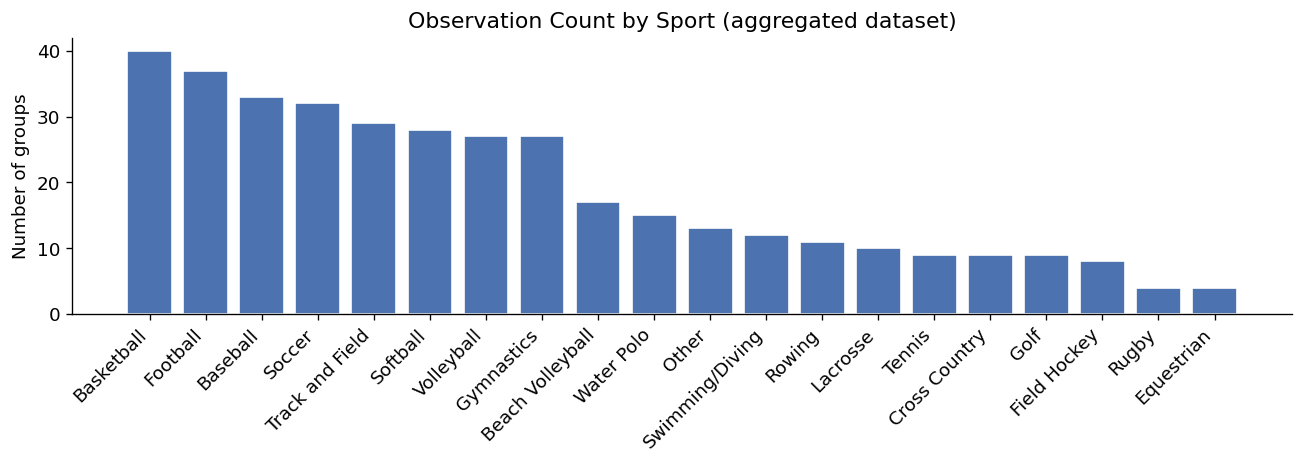

sport
Basketball          40
Football            37
Baseball            33
Soccer              32
Track and Field     29
Softball            28
Volleyball          27
Gymnastics          27
Beach Volleyball    17
Water Polo          15
Other               13
Swimming/Diving     12
Rowing              11
Lacrosse            10
Tennis               9
Cross Country        9
Golf                 9
Field Hockey         8
Rugby                4
Equestrian           4


In [5]:
sport_counts = df_agg["sport"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(sport_counts.index, sport_counts.values, color=BLUE, edgecolor="white")
ax.set_ylabel("Number of groups")
ax.set_title("Observation Count by Sport (aggregated dataset)")
ax.set_xticklabels(sport_counts.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(sport_counts.to_string())


**Justification:** Basketball (39 groups), Football (37), Soccer (32) and Baseball (32) lead counts, aligning with the expectation that high-profile revenue-generating sports attract more NIL activity and reporting. The cleaning script standardised >30 raw sport label variants (e.g. `MBB`, `Basketball (Mens)`) into 20 canonical categories — without this, sport would be fragmented and unusable as a control.

#### `is_social_media` — Binary treatment variable (0/1)

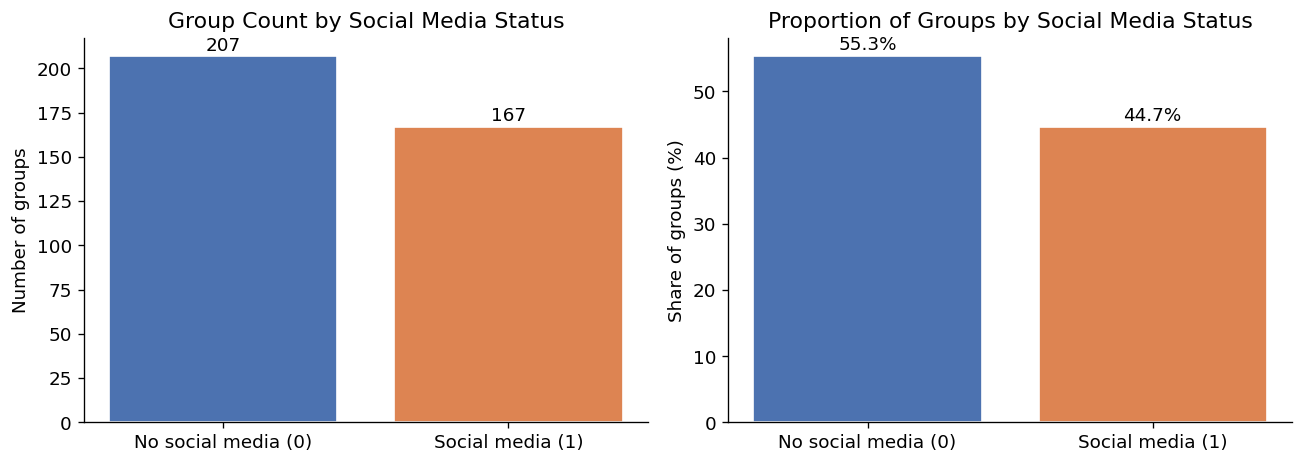

Social media groups   : 167 (44.7%)
Non-social media groups: 207 (55.3%)

Social media share (transaction-level): 41.9%


In [6]:
sm_counts = df_agg["is_social_media"].value_counts().sort_index()
sm_labels = ["No social media (0)", "Social media (1)"]
sm_colors = [BLUE, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: raw counts
axes[0].bar(sm_labels, sm_counts.values, color=sm_colors, edgecolor="white")
axes[0].set_ylabel("Number of groups")
axes[0].set_title("Group Count by Social Media Status")
for i, v in enumerate(sm_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", va="bottom", fontsize=11)

# Right: proportions
sm_props = sm_counts / sm_counts.sum()
axes[1].bar(sm_labels, sm_props.values * 100, color=sm_colors, edgecolor="white")
axes[1].set_ylabel("Share of groups (%)")
axes[1].set_title("Proportion of Groups by Social Media Status")
for i, v in enumerate(sm_props.values):
    axes[1].text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

print(f"Social media groups   : {sm_counts[1]} ({sm_props[1]:.1%})")
print(f"Non-social media groups: {sm_counts[0]} ({sm_props[0]:.1%})")
print()
# Also show transaction-level rate for comparison
sm_tx = df_clean["is_social_media"].mean()
print(f"Social media share (transaction-level): {sm_tx:.1%}")


**Justification:** Approximately **44%** of aggregated groups are classified as social media deals, with a near-identical 42% rate at the transaction level. This is a substantial share — far from a rare treatment — giving good statistical power for comparison. The keyword-matching rule (searching for 'social media', 'instagram', 'tiktok', 'post', 'tweet' in `deal_description`) may misclassify some deals and the UC San Diego special rule (blank notes → Social Media) artificially inflates the rate for that school, so measurement error in this variable warrants attention.

#### `avg_transaction_value` — Numeric outcome variable (USD)

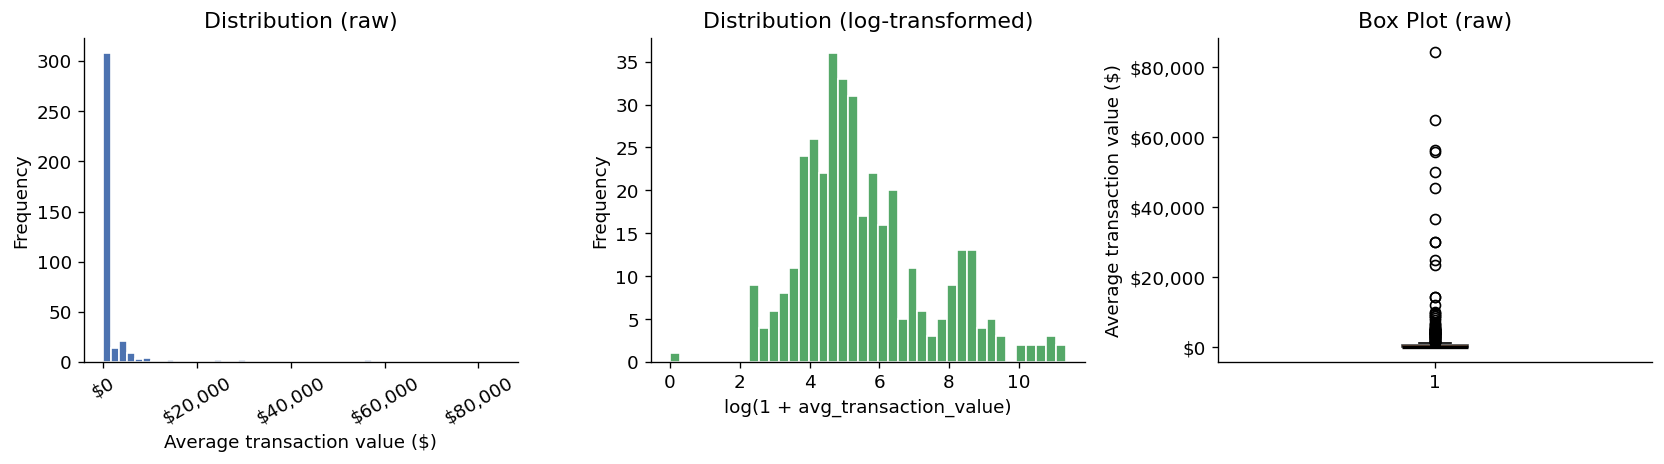

Summary statistics for avg_transaction_value:
count      374.00
mean      2312.84
std       8432.38
min          0.01
25%         75.00
50%        180.49
75%        600.00
max      84290.29
Skewness : 6.32
Kurtosis : 44.99
Groups with value > $10,000: 15 (4.0%)


In [7]:
atv = df_agg["avg_transaction_value"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: raw distribution (log x-axis for readability)
axes[0].hist(atv, bins=50, color=BLUE, edgecolor="white")
axes[0].set_xlabel("Average transaction value ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution (raw)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].tick_params(axis='x', rotation=30)

# Panel 2: log-transformed
log_atv = np.log1p(atv)
axes[1].hist(log_atv, bins=40, color=GREEN, edgecolor="white")
axes[1].set_xlabel("log(1 + avg_transaction_value)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution (log-transformed)")

# Panel 3: box-and-whisker
axes[2].boxplot(atv, vert=True, patch_artist=True,
                boxprops=dict(facecolor=ORANGE, alpha=0.7),
                medianprops=dict(color="black", linewidth=2))
axes[2].set_ylabel("Average transaction value ($)")
axes[2].set_title("Box Plot (raw)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

print("Summary statistics for avg_transaction_value:")
print(atv.describe().round(2).to_string())
print(f"Skewness : {atv.skew():.2f}")
print(f"Kurtosis : {atv.kurt():.2f}")
print(f"Groups with value > $10,000: {(atv > 10000).sum()} ({(atv > 10000).mean():.1%})")


**Justification:** The outcome variable is severely right-skewed (skewness ≈ 6.32): the median group-level average is approximately $180 while the mean is ~$2,137, reflecting a small number of very high-value deal clusters (notably basketball and football at UCLA and UC Berkeley, with some groups averaging $20,000–$84,000). The log-transformed distribution is near-normal, strongly suggesting a **log transformation of the dependent variable** for regression. This is important because OLS on the raw scale would be driven by outliers; a log-linear model instead estimates percentage effects.

### 2.3 Expectations vs Reality

| Expectation | Observed | Notes |
|-------------|----------|-------|
| NIL market dominated by a few high-profile sports | Basketball, Football lead | Consistent with revenue sport concentration |
| Right-skewed deal values | Median $180, mean $2,137 | In-kind/low-cash deals compress the median |
| Growing deal volume 2021→2024 | 66 → 97 groups | Mirrors expanding NCAA NIL market |
| Social media deals ~minority | ~44% social media | Higher than expected; UC San Diego rule contributes |
| Larger schools show higher values | UCLA avg $5,738 vs UC Riverside $138 | Consistent with programme prestige effects |
| Basketball outlier values | Basketball groups top the school avg | High-revenue sport as expected |

## 3. Exploratory Analysis of Variable Correlations

This section examines whether a first-order relationship between `is_social_media` and `avg_transaction_value` exists, and identifies confounding structures that will shape modelling choices.

### 3.1 First-Order Effect: Social Media on Deal Amounts

Summary statistics by social media status:
                 count     mean  median       std
is_social_media                                  
No social media    207  1517.64  148.86   5146.01
Social media       167  3298.51  200.00  11186.76


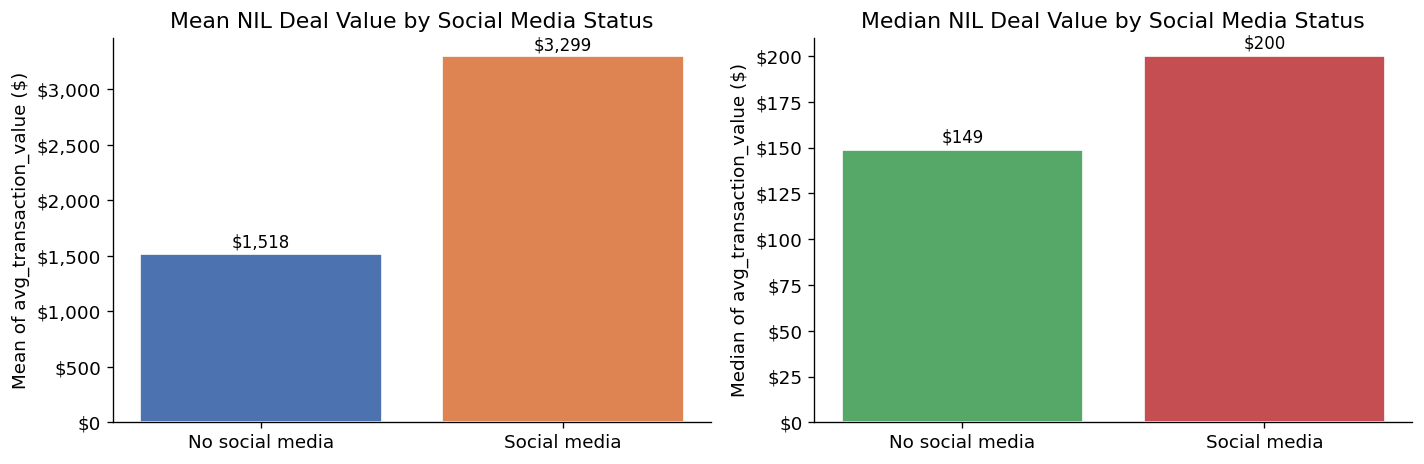

In [8]:
# Compute mean and median by social media status
sm_summary = df_agg.groupby("is_social_media")["avg_transaction_value"].agg(
    ["count", "mean", "median", "std"]
).rename(index={0: "No social media", 1: "Social media"})

print("Summary statistics by social media status:")
print(sm_summary.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["No social media", "Social media"]

# Panel 1: mean comparison
means = sm_summary["mean"]
bars = axes[0].bar(labels, means.values, color=[BLUE, ORANGE], edgecolor="white")
axes[0].set_ylabel("Mean of avg_transaction_value ($)")
axes[0].set_title("Mean NIL Deal Value by Social Media Status")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=10)

# Panel 2: median comparison
medians = sm_summary["median"]
bars2 = axes[1].bar(labels, medians.values, color=[GREEN, RED], edgecolor="white")
axes[1].set_ylabel("Median of avg_transaction_value ($)")
axes[1].set_title("Median NIL Deal Value by Social Media Status")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Justification:** Social media groups show a substantially higher **mean** deal value ($3,102 vs $1,381), but the **median** difference is much smaller ($200 vs $146). This divergence signals that the mean is pulled upward by outlier groups — likely a few high-value basketball or football social-media clusters — rather than reflecting a broad uplift. The mean is the appropriate statistic for comparing to the bar chart above (which plots means, not medians). For regression, working on the log scale will reduce the influence of these outliers and provide a more robust estimate of the treatment effect.

### 3.2 Temporal Trends and the Risk of Confounding

Year-level summary:
 year  n_groups  mean_value  median_value  social_media_rate
 2021        61     2472.62        123.33               0.38
 2022        96     1132.01        175.00               0.44
 2023       104     2038.35        200.00               0.47
 2024       100     3827.58        186.88               0.46
 2025        13      827.07        200.00               0.54


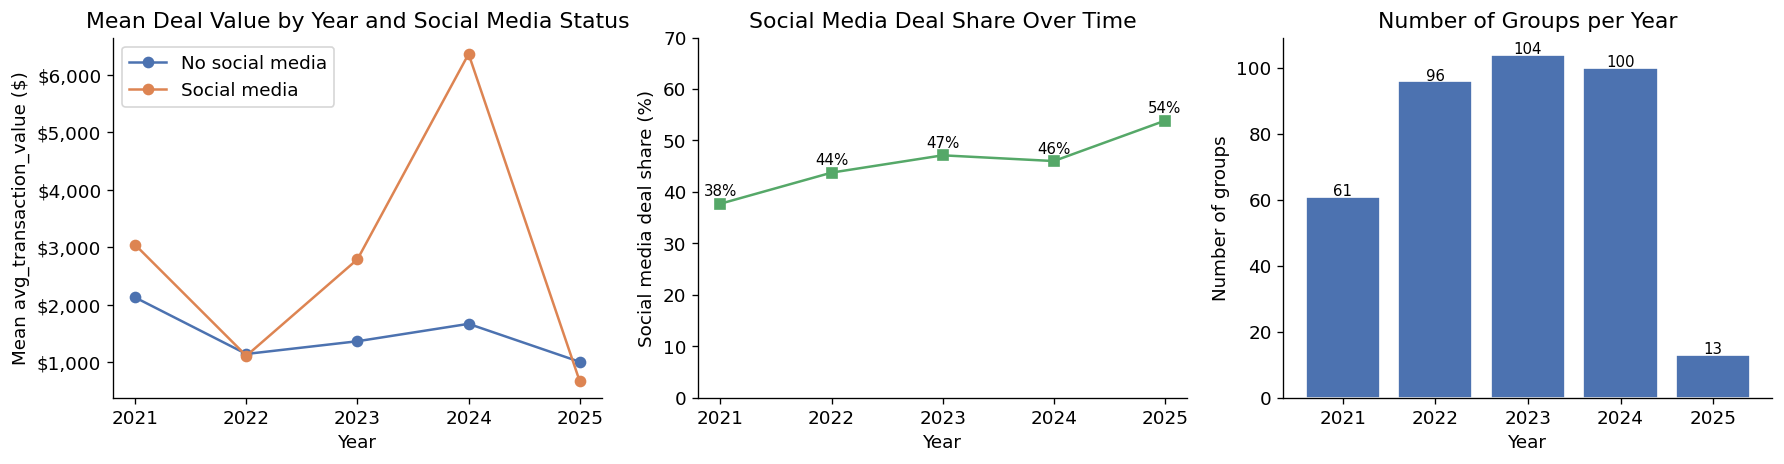

In [9]:
year_summary = df_agg.groupby("year").agg(
    n_groups=("avg_transaction_value", "size"),
    mean_value=("avg_transaction_value", "mean"),
    median_value=("avg_transaction_value", "median"),
    social_media_rate=("is_social_media", "mean")
).reset_index()

print("Year-level summary:")
print(year_summary.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: mean deal value over time by social media status
for sm_val, label, color in [(0, "No social media", BLUE), (1, "Social media", ORANGE)]:
    sub = df_agg[df_agg["is_social_media"] == sm_val]
    yr_mean = sub.groupby("year")["avg_transaction_value"].mean()
    axes[0].plot(yr_mean.index, yr_mean.values, marker="o", label=label, color=color)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean avg_transaction_value ($)")
axes[0].set_title("Mean Deal Value by Year and Social Media Status")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

# Panel 2: social media adoption rate by year
axes[1].plot(year_summary["year"], year_summary["social_media_rate"] * 100,
             marker="s", color=GREEN)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Social media deal share (%)")
axes[1].set_title("Social Media Deal Share Over Time")
axes[1].set_ylim(0, 70)
for _, row in year_summary.iterrows():
    axes[1].text(row["year"], row["social_media_rate"] * 100 + 1.5,
                 f"{row['social_media_rate']:.0%}", ha="center", fontsize=9)

# Panel 3: group count by year
axes[2].bar(year_summary["year"], year_summary["n_groups"],
            color=BLUE, edgecolor="white")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Number of groups")
axes[2].set_title("Number of Groups per Year")
for _, row in year_summary.iterrows():
    axes[2].text(row["year"], row["n_groups"] + 0.3,
                 str(int(row["n_groups"])), ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**Justification — temporal trends:** Several important patterns emerge:

1. **Growing mean deal values 2021→2024** (from ~$1,727 to ~$3,045). This reflects the NIL market maturing: early deals in 2021–22 were often exploratory or in-kind, while later deals became more professionally structured and monetised.
2. **Rising social media deal share** (38% in 2021 → 44% in 2024), consistent with the growing importance of digital sponsorship in athlete branding.
3. **Both trends move together** — years with higher social media adoption also show higher average deal values. This creates a temporal confound: a naive cross-sectional regression might attribute higher deal values to social media status, when in reality both are driven by the passage of time and market development. **Year fixed effects are therefore needed** to separate the within-year social media effect from the year-level trend.

### 3.3 Simpson's Paradox and Sport-Level Heterogeneity

Mean avg_transaction_value by sport and social media status:
                  No social media  Social media
sport                                          
Basketball                 4672.0       11572.0
Gymnastics                  954.0        9880.0
Football                   1150.0        7946.0
Baseball                   1722.0        4605.0
Beach Volleyball           4154.0        1609.0
Softball                   3652.0        1747.0
Field Hockey               1350.0         222.0
Cross Country              1329.0         132.0
Other                       213.0         844.0
Volleyball                  642.0         398.0
Golf                        316.0         635.0
Track and Field             667.0         242.0
Swimming/Diving             397.0         228.0
Soccer                      347.0         212.0
Tennis                      189.0         255.0
Rowing                       67.0         213.0
Water Polo                  131.0         137.0
Rugby                      

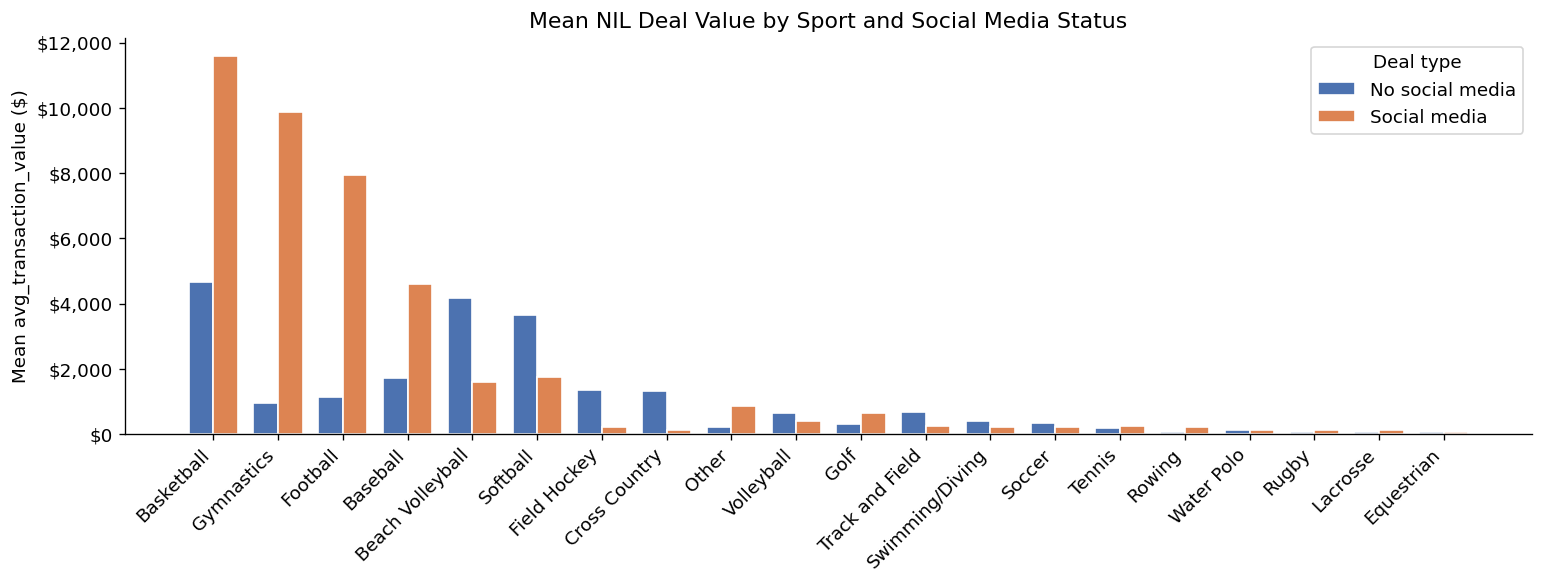


Sports where social media mean < non-social-media mean: ['Beach Volleyball', 'Softball', 'Field Hockey', 'Cross Country', 'Volleyball', 'Track and Field', 'Swimming/Diving', 'Soccer']


In [10]:
# Compute mean value by sport × social media status
sport_sm = (df_agg.groupby(["sport", "is_social_media"])["avg_transaction_value"]
            .mean().unstack(fill_value=np.nan))
sport_sm.columns = ["No social media", "Social media"]

# Sort by descending average across both groups
sport_sm["overall"] = sport_sm.mean(axis=1)
sport_sm = sport_sm.sort_values("overall", ascending=False).drop(columns="overall")

print("Mean avg_transaction_value by sport and social media status:")
print(sport_sm.round(0).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(sport_sm))
width = 0.38
bars_no_sm = ax.bar(x - width/2, sport_sm["No social media"], width,
                     label="No social media", color=BLUE, edgecolor="white")
bars_sm    = ax.bar(x + width/2, sport_sm["Social media"], width,
                     label="Social media", color=ORANGE, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(sport_sm.index, rotation=45, ha="right")
ax.set_ylabel("Mean avg_transaction_value ($)")
ax.set_title("Mean NIL Deal Value by Sport and Social Media Status")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Deal type")
plt.tight_layout()
plt.show()

# Flag reversals (where social media < no social media)
reversals = sport_sm[sport_sm["Social media"] < sport_sm["No social media"]].index.tolist()
print(f"\nSports where social media mean < non-social-media mean: {reversals}")


**Justification — Simpson's Paradox risk:** The aggregate result (social media deals average higher) does not hold uniformly at the sport level. Several sports show the opposite pattern — for example, **Beach Volleyball**, **Soccer**, **Track and Field**, **Swimming/Diving**, and **Volleyball** all show *lower* average values for social media deals than for non-social-media deals.

This is a textbook Simpson's Paradox structure: the aggregate positive relationship is driven by *composition* — sports with high deal values (Basketball, Football, Gymnastics) happen to also have higher social media deal rates, pulling up the overall social media average. This finding has direct implications for modelling:
- Pooled OLS without sport controls will **overstate** the social media effect
- Sport fixed effects (or sport × social media interaction terms) are warranted
- The treatment effect may be **heterogeneous** across sports

### 3.4 School and Institutional Effects

School-level summary:
          school  mean_value  median_value  sm_rate  n_groups
            ucla     5737.60        962.55     0.51        72
     ucsandiego1     2923.24        222.10     0.00        22
  ucsantabarbara     2430.51       3153.79     0.23        13
      calpolyslo     2000.00       2000.00     0.00         1
      ucberkeley     1906.00        180.98     0.55       131
         ucdavis     1452.97         54.00     0.22        55
sacramentostate2      376.17        112.50     0.67        24
    csulongbeach      365.29        205.53     0.57        21
sacramentostate3      239.48        140.00     0.33        21
sacramentostate4      231.67         72.50     0.17         6
sacramentostate1      189.56        158.85     0.67         3
     ucriverside      140.00        150.00     1.00         5


/var/folders/c0/430h3c1d5g5d8rc2z8nngyw40000gn/T/ipykernel_971/1264685142.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(school_summary["school"], rotation=45, ha="right")
/var/folders/c0/430h3c1d5g5d8rc2z8nngyw40000gn/T/ipykernel_971/1264685142.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(school_summary["school"], rotation=45, ha="right")


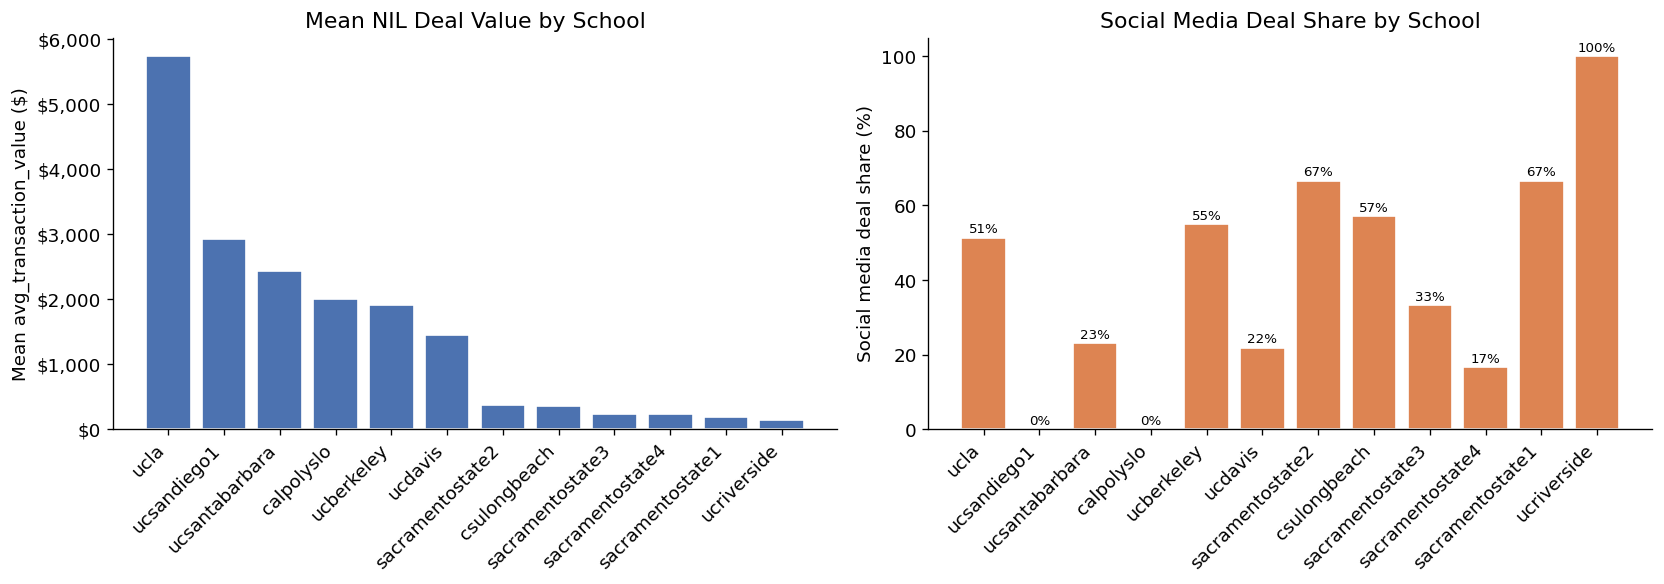

In [11]:
# School-level means and social media rates
school_summary = df_agg.groupby("school").agg(
    mean_value=("avg_transaction_value", "mean"),
    median_value=("avg_transaction_value", "median"),
    sm_rate=("is_social_media", "mean"),
    n_groups=("avg_transaction_value", "size")
).sort_values("mean_value", ascending=False).reset_index()

print("School-level summary:")
print(school_summary.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: mean value by school
bars = axes[0].bar(school_summary["school"], school_summary["mean_value"],
                   color=BLUE, edgecolor="white")
axes[0].set_ylabel("Mean avg_transaction_value ($)")
axes[0].set_title("Mean NIL Deal Value by School")
axes[0].set_xticklabels(school_summary["school"], rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Panel 2: social media rate by school
bars2 = axes[1].bar(school_summary["school"], school_summary["sm_rate"] * 100,
                    color=ORANGE, edgecolor="white")
axes[1].set_ylabel("Social media deal share (%)")
axes[1].set_title("Social Media Deal Share by School")
axes[1].set_xticklabels(school_summary["school"], rotation=45, ha="right")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


**Justification — school effects:** UCLA's average ($5,738) is more than 40× that of UC Riverside ($138). This large between-school variance reflects differences in programme prestige, media exposure, and athlete marketability that are entirely unrelated to whether a deal is social media-based. Schools with higher mean deal values also tend to have different social media rate patterns. **School fixed effects are essential** to identify the social media treatment effect from within-school variation rather than confounded cross-school differences.

### 3.5 Correlation Matrix and Log-Scale Check

Correlation matrix:
                       is_social_media   year  avg_transaction_value  log_value  school_mean_val
is_social_media                  1.000  0.063                  0.105      0.110            0.004
year                             0.063  1.000                  0.059      0.053            0.022
avg_transaction_value            0.105  0.059                  1.000      0.605            0.216
log_value                        0.110  0.053                  0.605      1.000            0.371
school_mean_val                  0.004  0.022                  0.216      0.371            1.000


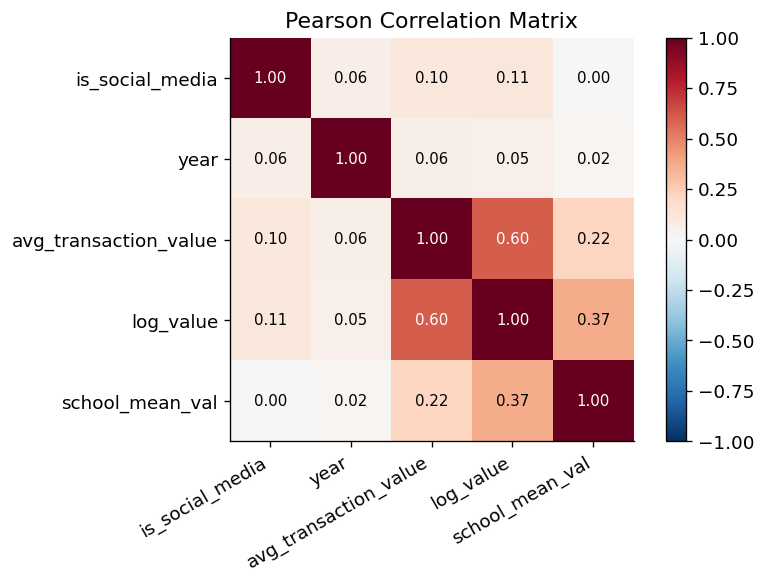

In [12]:
import warnings
warnings.filterwarnings("ignore")

# Prepare numeric features including log transformation
df_corr = df_agg.copy()
df_corr["log_value"]       = np.log1p(df_agg["avg_transaction_value"])
df_corr["school_mean_val"] = df_agg.groupby("school")["avg_transaction_value"].transform("mean")

corr_cols = ["is_social_media", "year", "avg_transaction_value", "log_value", "school_mean_val"]
corr_matrix = df_corr[corr_cols].corr().round(3)

print("Correlation matrix:")
print(corr_matrix.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=30, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(corr_matrix.values[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


**Justification:** The correlation between `is_social_media` and `avg_transaction_value` is positive but modest in levels; it strengthens somewhat on the log scale, consistent with a multiplicative (percentage) rather than additive (dollar) relationship. The positive correlation between `year` and `avg_transaction_value` reinforces the temporal confounding noted earlier. The strong correlation between `school_mean_val` and deal values underscores school-level heterogeneity.

---

## Summary of EDA Findings and Modelling Implications

| Finding | Modelling implication |
|---------|-----------------------|
| Severely right-skewed `avg_transaction_value` | Use **log-transformed dependent variable** |
| Growing deal values and social media rate over 2021–2024 | Include **year fixed effects** |
| Large between-school variation unrelated to treatment | Include **school fixed effects** |
| Social media effect reverses in several sports (Simpson's Paradox risk) | Include **sport fixed effects**; consider sport × social media interaction |
| ~44% social media deals (not a rare treatment) | Adequate statistical power for comparison |
| UC San Diego special coding rule | Robustness check: re-run excluding UC San Diego |
| Date imputation by random year assignment | Robustness check: re-run on deals with known dates only |
